In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import torch

import sys
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution
from tqdm import tqdm

sys.path.append("../../")
from utils.plotting import make_corner
from utils.mahaTools import mahalanobis_dist
from utils.ANALYSISutils import median_score

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
n100 = ["Nref6296_Nbkg400_Nsig100_8t_alt.npy","Nref6296_Nbkg400_Nsig100_8t_null.npy"]
n50 = ["Nref6296_Nbkg450_Nsig50_8t_alt.npy","Nref6296_Nbkg450_Nsig50_8t_null.npy"]
n25 = ["Nref6296_Nbkg475_Nsig25_8t_alt.npy","Nref6296_Nbkg475_Nsig25_8t_null.npy"]
n10 = ["Nref6296_Nbkg490_Nsig10_8t_alt.npy","Nref6296_Nbkg490_Nsig10_8t_null.npy"]

bkg_tot = 500
files = {
    10/500:n10,
    25/500:n25,
    50/500:n50,
    100/500:n100
}
sig_fracs = sorted(list(files.keys()))

In [3]:
base = "Mahalanobis_histology/"
zscores = []
for sf in sig_fracs:
    null = np.load(base+files[sf][1])
    alt = np.load(base+files[sf][0])
    t_empirical = np.sum(1.*(null>np.mean(alt)))*1./null.shape[0]
    if t_empirical==0:
        t_empirical = 1./null.shape[0]
    z = norm.ppf(1-t_empirical)
    zscores.append(z)

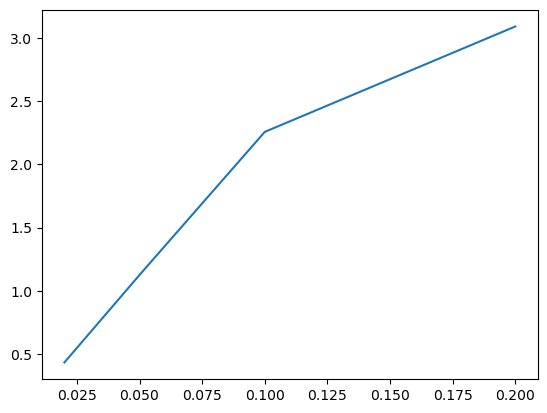

In [4]:
plt.plot(sig_fracs,zscores)

In [5]:
np.savez("histology_maha_empiricalZscore.npz",zscores=zscores,fracs=sig_fracs)